# Outlier Detection

In [4]:
import sys
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, str(Path(os.getcwd()).parent.parent))

from src.utils.config import PCA_CSV_DIR, PCA_IMAGE_DIR, OUTPUTS_DIR

OUTLIER_IMAGE_DIR = os.path.join(OUTPUTS_DIR, "output_images", "05_outliers")
OUTLIER_CSV_DIR = os.path.join(PCA_CSV_DIR, "05_outliers")
os.makedirs(OUTLIER_IMAGE_DIR, exist_ok=True)
os.makedirs(OUTLIER_CSV_DIR, exist_ok=True)

print("Import Complete")
print("OUTLIER_IMAGE_DIR:", OUTLIER_IMAGE_DIR)
print("OUTLIER_CSV_DIR:", OUTLIER_CSV_DIR)

Import Complete
OUTLIER_IMAGE_DIR: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/output_images/05_outliers
OUTLIER_CSV_DIR: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/05_outliers


# # Load individual PCA scores (saved in notebook 04)

In [5]:
# Load individual PCA scores (saved in notebook 04)
placenta_pca_df = pd.read_csv(os.path.join(PCA_CSV_DIR, "pca_placenta_only.csv"), index_col='Sample')
cord_pca_df     = pd.read_csv(os.path.join(PCA_CSV_DIR, "pca_cord_only.csv"),     index_col='Sample')

print(f"Placenta PCA scores: {placenta_pca_df.shape}")
print(f"Cord PCA scores:     {cord_pca_df.shape}")
print(f"\nPlacenta columns: {placenta_pca_df.columns.tolist()}")

print("\nPlacenta preview (PC1, PC2):")
display(placenta_pca_df[["PC1", "PC2"]].head())

print("Cord preview (PC1, PC2):")
display(cord_pca_df[["PC1", "PC2"]].head())

Placenta PCA scores: (40, 10)
Cord PCA scores:     (38, 10)

Placenta columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10']

Placenta preview (PC1, PC2):


,PC1,PC2
Sample,,
sample-1,-1.836882,9.674800
sample-2,5.119141,-5.977017
sample-3,5.093578,14.212926
sample-4,-8.885906,6.307899
sample-5,5.511009,5.872692


Cord preview (PC1, PC2):


,PC1,PC2
Sample,,
sample-1,-3.121207,2.049936
sample-2,-4.443159,2.927280
sample-3,-5.233151,-2.264805
sample-4,-3.450644,-1.853362
sample-5,-11.465463,-4.958626


In [6]:
# Step 3: Flag outliers in a table (PC1 / PC2 / Any)
threshold = 20

if 'OUTLIER_IMAGE_DIR' not in globals() or 'OUTLIER_CSV_DIR' not in globals():
    OUTLIER_IMAGE_DIR = os.path.join(OUTPUTS_DIR, "output_images", "05_outliers")
    OUTLIER_CSV_DIR = os.path.join(PCA_CSV_DIR, "05_outliers")
os.makedirs(OUTLIER_IMAGE_DIR, exist_ok=True)
os.makedirs(OUTLIER_CSV_DIR, exist_ok=True)

def flag_outliers(df, thr=20):
    flagged = df.copy()
    flagged['PC1_outlier'] = flagged['PC1'].abs() > thr
    flagged['PC2_outlier'] = flagged['PC2'].abs() > thr
    flagged['Any_outlier'] = flagged['PC1_outlier'] | flagged['PC2_outlier']
    flagged['PC1_flag'] = np.where(flagged['PC1'] > thr, 'high', np.where(flagged['PC1'] < -thr, 'low', 'normal'))
    flagged['PC2_flag'] = np.where(flagged['PC2'] > thr, 'high', np.where(flagged['PC2'] < -thr, 'low', 'normal'))
    return flagged

placenta_flagged = flag_outliers(placenta_pca_df, threshold)
cord_flagged = flag_outliers(cord_pca_df, threshold)

placenta_flagged_outliers = placenta_flagged[placenta_flagged['Any_outlier']].copy()
cord_flagged_outliers = cord_flagged[cord_flagged['Any_outlier']].copy()

placenta_flagged.to_csv(os.path.join(OUTLIER_CSV_DIR, 'placenta_outlier_flags_all_samples.csv'))
cord_flagged.to_csv(os.path.join(OUTLIER_CSV_DIR, 'cord_outlier_flags_all_samples.csv'))
placenta_flagged_outliers.to_csv(os.path.join(OUTLIER_CSV_DIR, 'placenta_outliers_only.csv'))
cord_flagged_outliers.to_csv(os.path.join(OUTLIER_CSV_DIR, 'cord_outliers_only.csv'))

print(f"Threshold used: ±{threshold}")
print(f"Placenta flagged outliers: {placenta_flagged_outliers.shape[0]}")
print(f"Cord flagged outliers: {cord_flagged_outliers.shape[0]}")

print("\nPlacenta flagged outliers:")
display(placenta_flagged_outliers[['PC1', 'PC2', 'PC1_flag', 'PC2_flag', 'Any_outlier']])

print("Cord flagged outliers:")
display(cord_flagged_outliers[['PC1', 'PC2', 'PC1_flag', 'PC2_flag', 'Any_outlier']])

print(f"\nSaved files in: {OUTLIER_CSV_DIR}")

Threshold used: ±20
Placenta flagged outliers: 3
Cord flagged outliers: 7

Placenta flagged outliers:


,PC1,PC2,PC1_flag,PC2_flag,Any_outlier
Sample,,,,,
sample-12,-36.691306,26.244922,low,high,True
sample-22,-53.073995,-30.217184,low,low,True
sample-25,-33.996374,-20.510591,low,low,True


Cord flagged outliers:


,PC1,PC2,PC1_flag,PC2_flag,Any_outlier
Sample,,,,,
sample-20,45.236285,5.479976,high,normal,True
sample-22,30.626956,-2.253874,high,normal,True
sample-23,31.293148,-17.041820,high,normal,True
sample-25,20.798455,-23.967596,high,low,True
sample-29,24.054354,12.486996,high,normal,True
sample-33,17.898470,-21.774582,normal,low,True
sample-37,15.400208,23.000656,normal,high,True



Saved files in: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/05_outliers


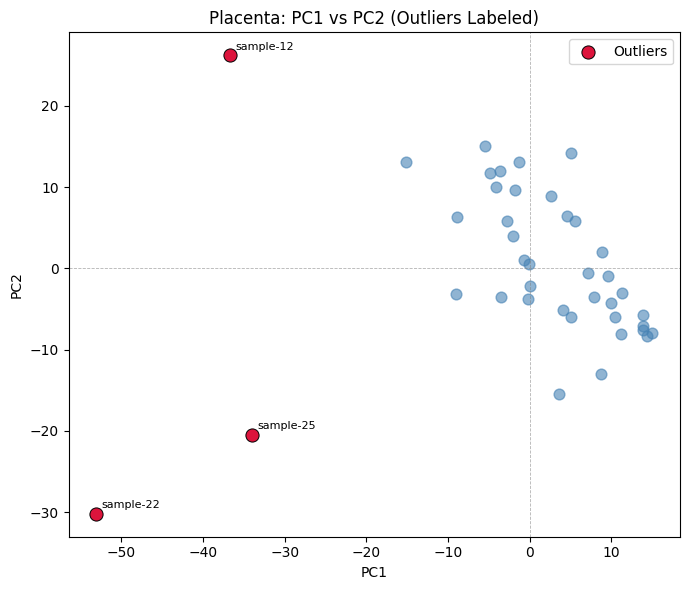

Saved: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/output_images/05_outliers/placenta_pc1_pc2_outliers_labeled.png


In [7]:
# Step 4A: Placenta PC1 vs PC2 (label only flagged outlier samples)
plt.figure(figsize=(7, 6))
plt.scatter(placenta_flagged['PC1'], placenta_flagged['PC2'], color='steelblue', alpha=0.6, s=60)
plt.scatter(
    placenta_flagged_outliers['PC1'],
    placenta_flagged_outliers['PC2'],
    color='crimson', edgecolors='black', linewidths=0.7, s=90, label='Outliers', zorder=3
)

for sample, row in placenta_flagged_outliers.iterrows():
    plt.annotate(sample, (row['PC1'], row['PC2']), xytext=(4, 4), textcoords='offset points', fontsize=8)

plt.axhline(0, color='grey', linestyle='--', linewidth=0.6, alpha=0.6)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.6, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Placenta: PC1 vs PC2 (Outliers Labeled)')
plt.legend()
plt.tight_layout()

placenta_plot_path = os.path.join(OUTLIER_IMAGE_DIR, 'placenta_pc1_pc2_outliers_labeled.png')
plt.savefig(placenta_plot_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Saved: {placenta_plot_path}')

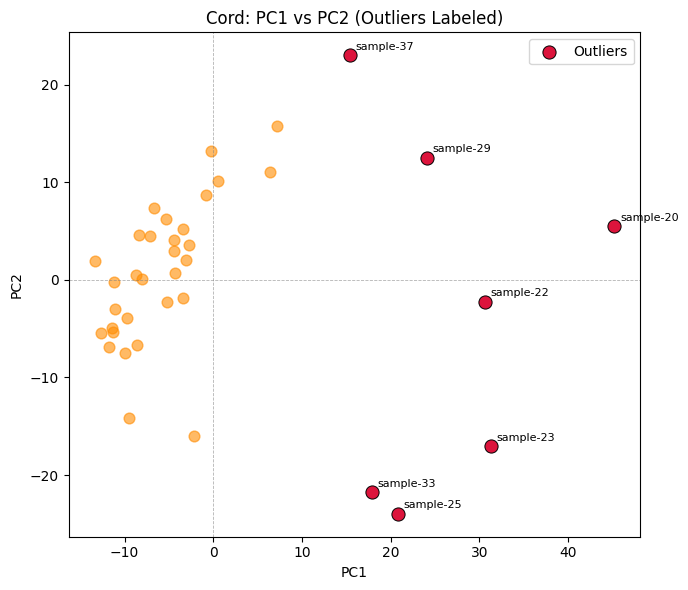

Saved: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/output_images/05_outliers/cord_pc1_pc2_outliers_labeled.png


In [8]:
# Step 4B: Cord PC1 vs PC2 (label only flagged outlier samples)
plt.figure(figsize=(7, 6))
plt.scatter(cord_flagged['PC1'], cord_flagged['PC2'], color='darkorange', alpha=0.6, s=60)
plt.scatter(
    cord_flagged_outliers['PC1'],
    cord_flagged_outliers['PC2'],
    color='crimson', edgecolors='black', linewidths=0.7, s=90, label='Outliers', zorder=3
)

for sample, row in cord_flagged_outliers.iterrows():
    plt.annotate(sample, (row['PC1'], row['PC2']), xytext=(4, 4), textcoords='offset points', fontsize=8)

plt.axhline(0, color='grey', linestyle='--', linewidth=0.6, alpha=0.6)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.6, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Cord: PC1 vs PC2 (Outliers Labeled)')
plt.legend()
plt.tight_layout()

cord_plot_path = os.path.join(OUTLIER_IMAGE_DIR, 'cord_pc1_pc2_outliers_labeled.png')
plt.savefig(cord_plot_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Saved: {cord_plot_path}')

# Remove Outlier for Combined PCA

In [9]:
# Step 5: Combined PCA outlier flagging + removal (same logic as individual)
combined_path = os.path.join(PCA_CSV_DIR, 'pca_combined_placenta_cord.csv')
combined_pca_df = pd.read_csv(combined_path, index_col='Sample')

required_cols = {'PC1', 'PC2', 'Group'}
missing_cols = required_cols.difference(combined_pca_df.columns)
if missing_cols:
    raise ValueError(f"Combined PCA file missing columns: {missing_cols}")

threshold = 20
combined_flagged = combined_pca_df.copy()
combined_flagged['PC1_outlier'] = combined_flagged['PC1'].abs() > threshold
combined_flagged['PC2_outlier'] = combined_flagged['PC2'].abs() > threshold
combined_flagged['Any_outlier'] = combined_flagged['PC1_outlier'] | combined_flagged['PC2_outlier']
combined_flagged['PC1_flag'] = np.where(combined_flagged['PC1'] > threshold, 'high', np.where(combined_flagged['PC1'] < -threshold, 'low', 'normal'))
combined_flagged['PC2_flag'] = np.where(combined_flagged['PC2'] > threshold, 'high', np.where(combined_flagged['PC2'] < -threshold, 'low', 'normal'))

combined_outliers_only = combined_flagged[combined_flagged['Any_outlier']].copy()
combined_no_outliers = combined_flagged[~combined_flagged['Any_outlier']].copy()

# Save flagged / outlier tables
combined_flagged.to_csv(os.path.join(OUTLIER_CSV_DIR, 'combined_outlier_flags_all_samples.csv'))
combined_outliers_only.to_csv(os.path.join(OUTLIER_CSV_DIR, 'combined_outliers_only.csv'))

# Save cleaned combined PCA (outliers removed) into output_csv/05_outliers
cleaned_combined_path = os.path.join(OUTLIER_CSV_DIR, 'pca_combined_placenta_cord_no_outliers.csv')
combined_no_outliers.to_csv(cleaned_combined_path)

print(f"Combined total samples: {combined_flagged.shape[0]}")
print(f"Combined outliers: {combined_outliers_only.shape[0]}")
print(f"Combined remaining after removal: {combined_no_outliers.shape[0]}")
print("\nOutliers by group:")
print(combined_outliers_only['Group'].value_counts())
print(f"\nSaved cleaned file: {cleaned_combined_path}")



Combined total samples: 78
Combined outliers: 9
Combined remaining after removal: 69

Outliers by group:
Group
Cord        6
Placenta    3
Name: count, dtype: int64

Saved cleaned file: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/05_outliers/pca_combined_placenta_cord_no_outliers.csv


# Plot Combined Outlier

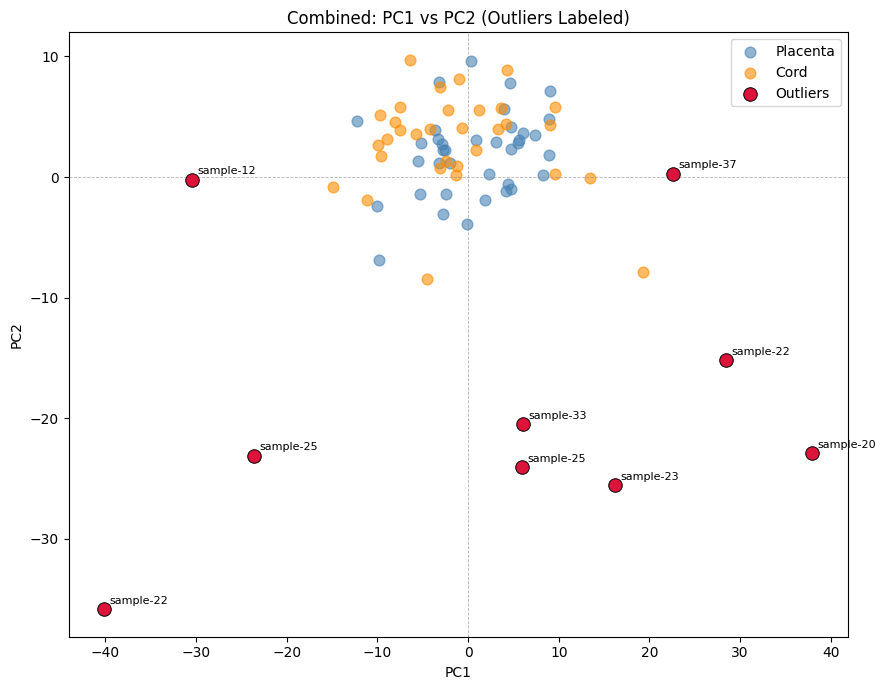

Saved plot: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/output_images/05_outliers/combined_pc1_pc2_outliers_labeled.png


In [10]:
# Plot combined PC1 vs PC2 and label only outliers
plt.figure(figsize=(9, 7))
for label, color in [('Placenta', 'steelblue'), ('Cord', 'darkorange')]:
    subset = combined_flagged[combined_flagged['Group'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], color=color, alpha=0.6, s=60, label=label)

plt.scatter(
    combined_outliers_only['PC1'],
    combined_outliers_only['PC2'],
    color='crimson', edgecolors='black', linewidths=0.7, s=95, label='Outliers', zorder=3
)
for sample, row in combined_outliers_only.iterrows():
    plt.annotate(sample, (row['PC1'], row['PC2']), xytext=(4, 4), textcoords='offset points', fontsize=8)

plt.axhline(0, color='grey', linestyle='--', linewidth=0.6, alpha=0.6)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.6, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Combined: PC1 vs PC2 (Outliers Labeled)')
plt.legend()
plt.tight_layout()

combined_plot_path = os.path.join(OUTLIER_IMAGE_DIR, 'combined_pc1_pc2_outliers_labeled.png')
plt.savefig(combined_plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved plot: {combined_plot_path}")